# Hypothesis Testing - Z-Test

**Assumption:** data → Normal Distribution

1. Population → mean ($\mu$), Std ($\sigma$) — **known**
2. Sample → Mean ($\bar{x}$)
3. No. of samples ($n$) $\geq$ 30

When the population standard deviation $\sigma$ is known and the sample size is large ($n \geq 30$), we use the **Z-test**.

## Z-Test Formula

$$z_{test} = \dfrac{\bar{x} - \mu}{\dfrac{\sigma}{\sqrt{n}}}$$

Where:
- $\bar{x}$ = Sample Mean
- $\mu$ = Population Mean
- $\sigma$ = Population Std (known)
- $n$ = No. of samples

Unlike the t-test, there's no `df` here — since $\sigma$ is known, we use the standard normal distribution directly, no correction needed for estimating std from the sample.

In [1]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

## Example 1 (Two-Tailed Z-Test)

The average height of all residents in a city is **168 cm**, with a population standard deviation $\sigma = 3.9$. A doctor believes the mean to be **different**. He measures the height of **36 individuals** and finds the average to be **169.5 cm**.

**(a)** State the null and alternate hypothesis.
**(b)** At a **95% confidence interval**, is there enough evidence to reject the null hypothesis?

**Given:**
- $\mu = 168$ cm (population mean)
- $\sigma = 3.9$ (population std)
- $n = 36$ (sample size)
- $\bar{x} = 169.5$ cm (sample mean)

### Step 1 - State the hypotheses

Since the doctor believes the mean is *different* (not specifically higher or lower), this is a **two-tailed test**.

$$H_0: \mu = 168 \text{ cm}$$
$$H_1: \mu \neq 168 \text{ cm} \quad \text{(two-tailed)}$$

### Step 2 - Significance level

$$CI = 0.95 \;(95\%) \implies \alpha = 1 - CI = 1 - 0.95 = 0.05$$

Because it's two-tailed, $\alpha$ splits equally between both tails:

$$\dfrac{\alpha}{2} = 0.025 \text{ on each side}$$

### Step 3 - Critical z-value (from z-table)

We need the z-value where the cumulative area is $1 - 0.025 = 0.975$:

$$z_{critical} = \pm 1.96$$

**Decision boundary:** the middle 95% (from $-1.96$ to $+1.96$) is the **acceptance region**. Anything beyond that, in either tail (2.5% each side), is the **rejection region**.

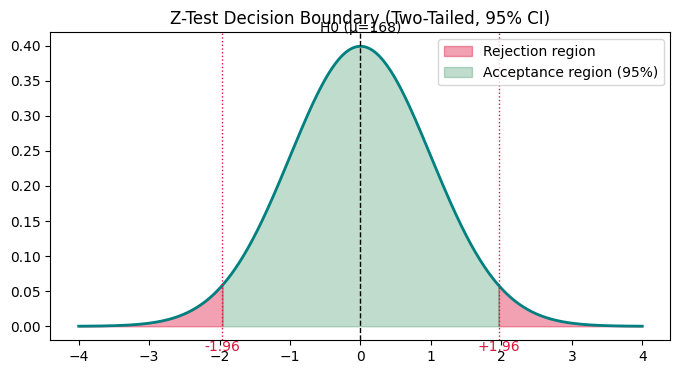

In [2]:
z_crit = st.norm.ppf(0.975)   # 1.96
x = np.linspace(-4, 4, 500)
y = st.norm.pdf(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# shade rejection regions (both tails)
x_left = np.linspace(-4, -z_crit, 100)
x_right = np.linspace(z_crit, 4, 100)
ax.fill_between(x_left, st.norm.pdf(x_left), color="crimson", alpha=0.4, label="Rejection region")
ax.fill_between(x_right, st.norm.pdf(x_right), color="crimson", alpha=0.4)

# acceptance region
x_mid = np.linspace(-z_crit, z_crit, 200)
ax.fill_between(x_mid, st.norm.pdf(x_mid), color="seagreen", alpha=0.3, label="Acceptance region (95%)")

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.text(0, max(y) * 1.05, "H0 (μ=168)", ha="center")
ax.axvline(-z_crit, color="crimson", linestyle=":", linewidth=1)
ax.axvline(z_crit, color="crimson", linestyle=":", linewidth=1)
ax.text(-z_crit, -0.02, "-1.96", ha="center", va="top", color="crimson")
ax.text(z_crit, -0.02, "+1.96", ha="center", va="top", color="crimson")

ax.legend()
ax.set_title("Z-Test Decision Boundary (Two-Tailed, 95% CI)")
plt.show()

### Step 4 - Calculate the test statistic

$$z_{test} = \dfrac{\bar{x} - \mu}{\dfrac{\sigma}{\sqrt{n}}} = \dfrac{169.5 - 168}{\dfrac{3.9}{\sqrt{36}}} = \dfrac{1.5}{0.65} \approx 2.31$$

### Step 5 - Decision rule

Reject $H_0$ if $z_{test}$ falls **outside** the acceptance region $[-1.96, +1.96]$:

$$z_{test} (2.31) > z_{critical} (1.96)$$

This is true — $z_{test}$ falls in the rejection region → **reject $H_0$, accept $H_1$**.

**Conclusion:** At the 95% confidence level, there is enough evidence that the average height of the 36 sampled individuals is significantly different from the city's population mean of 168 cm.

In [3]:
mu = 168
sigma = 3.9
n = 36
x_bar = 169.5
alpha = 0.05

z_critical = st.norm.ppf(1 - alpha / 2)   # two-tailed -> 1.96
z_test = (x_bar - mu) / (sigma / np.sqrt(n))

print("z_critical:", round(z_critical, 4))
print("z_test:", round(z_test, 4))

if abs(z_test) > z_critical:
    print("Reject H0 -> H1 is right (mean height is significantly different from 168cm)")
else:
    print("Fail to reject H0 -> H0 holds (no significant evidence mean differs from 168cm)")

z_critical: 1.96
z_test: 2.3077
Reject H0 -> H1 is right (mean height is significantly different from 168cm)


### Plotting the actual z_test value

The earlier plot only showed the critical boundaries ($\pm 1.96$). Here we mark the **actual computed value, $z_{test} = 2.31$**, on the same curve — this is what makes the decision visual.

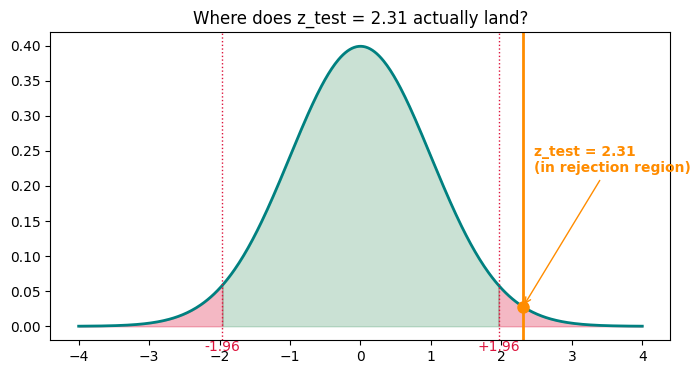

In [4]:
mu = 168
sigma = 3.9
n = 36
x_bar = 169.5
alpha = 0.05

z_critical = st.norm.ppf(1 - alpha / 2)
z_test = (x_bar - mu) / (sigma / np.sqrt(n))

x = np.linspace(-4, 4, 500)
y = st.norm.pdf(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection regions
x_left = np.linspace(-4, -z_critical, 100)
x_right = np.linspace(z_critical, 4, 100)
ax.fill_between(x_left, st.norm.pdf(x_left), color="crimson", alpha=0.3)
ax.fill_between(x_right, st.norm.pdf(x_right), color="crimson", alpha=0.3)

# acceptance region
x_mid = np.linspace(-z_critical, z_critical, 200)
ax.fill_between(x_mid, st.norm.pdf(x_mid), color="seagreen", alpha=0.25)

# critical boundaries
ax.axvline(-z_critical, color="crimson", linestyle=":", linewidth=1)
ax.axvline(z_critical, color="crimson", linestyle=":", linewidth=1)
ax.text(-z_critical, -0.02, f"-{z_critical:.2f}", ha="center", va="top", color="crimson")
ax.text(z_critical, -0.02, f"+{z_critical:.2f}", ha="center", va="top", color="crimson")

# actual test statistic, plotted on the curve
ax.axvline(z_test, color="darkorange", linewidth=2)
ax.plot(z_test, st.norm.pdf(z_test), "o", color="darkorange", markersize=8, zorder=5)
ax.annotate(f"z_test = {z_test:.2f}\n(in rejection region)",
            xy=(z_test, st.norm.pdf(z_test)),
            xytext=(z_test + 0.15, max(y) * 0.55),
            arrowprops=dict(arrowstyle="->", color="darkorange"),
            color="darkorange", fontweight="bold")

ax.set_title("Where does z_test = 2.31 actually land?")
plt.show()

---

## FAQ

**1. How do we decide the confidence level (95%, 99%...)?**

It isn't calculated from the data — it's chosen *in advance* based on how much Type I error (wrongly rejecting a true $H_0$) you're willing to accept. **95%** is the standard convention (5% risk). Use **99%** for high-stakes/safety-critical decisions (medicine, aviation), **90%** for exploratory work where being less strict is fine.

**2. In Step 2, where does $\alpha = 1 - CI$ come from?**

$CI$ is the area under the curve where we **correctly fail to reject** $H_0$ (the acceptance region). Total area under any probability distribution is always 1, so whatever isn't acceptance area must be rejection area:

$$\alpha = 1 - CI$$

For a **two-tailed** test, this total risk $\alpha$ is split equally between both tails ($\alpha/2$ each) — because before collecting data, we don't know which direction the deviation might go.

**3. How do we know it's two-tailed? Give a one-tailed example.**

- **Two-tailed** → $H_1$ uses "$\neq$" → we care about a difference in **either** direction (like our example: doctor just believes the mean is "different").
- **One-tailed** → $H_1$ uses "$>$" or "$<$" → we care about a difference in **only one specific** direction.

**One-tailed example:** A company claims its light bulbs last **1000 hours** on average. A new manufacturing process is believed to make bulbs last **longer** — not just "different", specifically *more*.

$$H_0: \mu = 1000 \qquad H_1: \mu > 1000 \quad \text{(right-tailed)}$$

Here all of $\alpha$ (say 0.05) sits in **one** tail, so $z_{critical} = 1.645$, not $1.96$ — a smaller critical value because we're not "spending" any risk on the left tail we don't care about.

### Two-Tailed vs One-Tailed — side by side

- **Left:** our height example — $H_1: \mu \neq 168$ — rejection region split into **both** tails ($\alpha/2$ each).
- **Right:** the bulb example from the FAQ — $H_1: \mu > 1000$ — rejection region entirely in the **right** tail ($\alpha$ in one tail, so the critical value is smaller: $1.645$ instead of $1.96$).

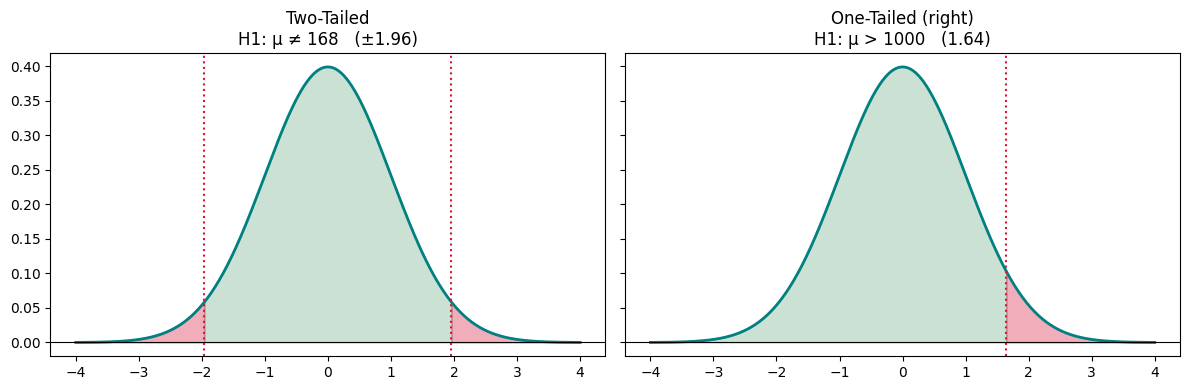

In [5]:
alpha = 0.05

z_two = st.norm.ppf(1 - alpha / 2)   # 1.96 -> split between both tails
z_one = st.norm.ppf(1 - alpha)       # 1.645 -> all alpha in one tail

x = np.linspace(-4, 4, 500)
y = st.norm.pdf(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# --- Two-tailed ---
ax = axes[0]
ax.plot(x, y, color="teal", linewidth=2)
x_l, x_r = np.linspace(-4, -z_two, 100), np.linspace(z_two, 4, 100)
ax.fill_between(x_l, st.norm.pdf(x_l), color="crimson", alpha=0.35)
ax.fill_between(x_r, st.norm.pdf(x_r), color="crimson", alpha=0.35)
x_mid = np.linspace(-z_two, z_two, 200)
ax.fill_between(x_mid, st.norm.pdf(x_mid), color="seagreen", alpha=0.25)
ax.axvline(-z_two, color="crimson", linestyle=":")
ax.axvline(z_two, color="crimson", linestyle=":")
ax.set_title(f"Two-Tailed\nH1: μ ≠ 168   (±{z_two:.2f})")

# --- One-tailed (right) ---
ax = axes[1]
ax.plot(x, y, color="teal", linewidth=2)
x_r = np.linspace(z_one, 4, 100)
ax.fill_between(x_r, st.norm.pdf(x_r), color="crimson", alpha=0.35)
x_mid = np.linspace(-4, z_one, 200)
ax.fill_between(x_mid, st.norm.pdf(x_mid), color="seagreen", alpha=0.25)
ax.axvline(z_one, color="crimson", linestyle=":")
ax.set_title(f"One-Tailed (right)\nH1: μ > 1000   ({z_one:.2f})")

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()